# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.5 MB


In [3]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [4]:
# Check for missing values
df.isnull().sum()
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [5]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

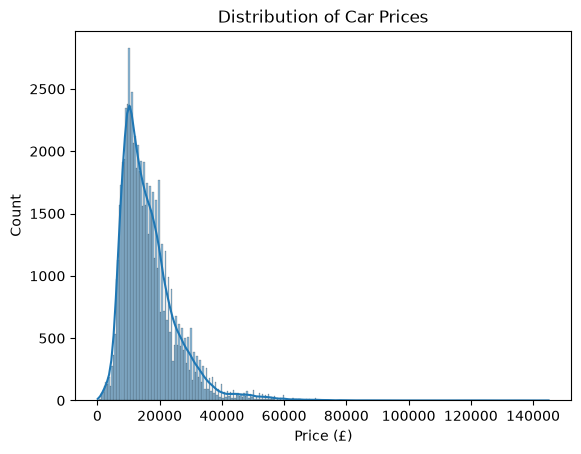

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins="auto", kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()

## Conclusions on Distribution of Car Prices

- The most common prices are approximately between 10,000 and 20,000 GBP;
- Most of the cars have a price below 30,000 GBP, showing that the dataset mainly contains affordable and mid-range vehicles;
- The maximum recorded price is around 145,000 GBP which is considerably higher than average, while the minimum recorded price is 99 GBP which is unusually low;
- Extremely low and extremely high prices should be inspected before model training to determine whether they represent valid vehicles or erroneous observations;
- Potential outliers should not be removed automatically, because legitimate luxury vehicles may contain important information that the regression model should learn;
- Although vehicles priced above 60.000 GBP are rare, they are not necessarily incorrect observations because some of them may represent legitimate luxury, premium or high-performance cars.

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

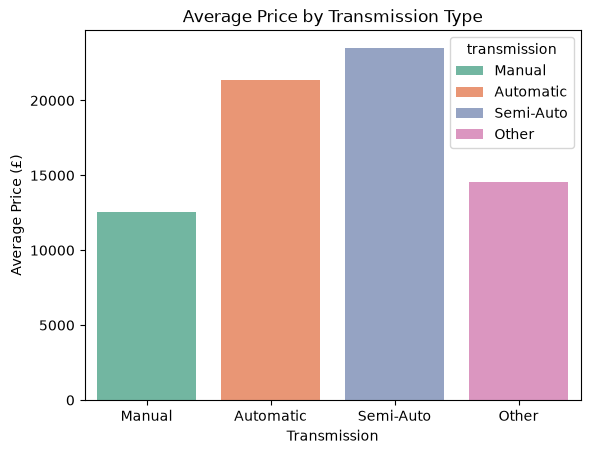

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

##  Conclusions on Average Price by Transmission Type

- Semi-automatic cars have the highest average price, at approximately 24,000 GBP;
- Automatic cars have the second-highest average price, at approximately 21,000 GBP;
- Manual cars have the lowest average price, at approximately 12,500 GBP;
- The average price of semi-automatic cars is almost twice as high as that of manual cars, indicating a considerable difference between these transmission categories;
- Semi-automatic and automatic transmissions are often found in newer, premium or high-performance vehicles, which may explain their higher average prices;
- Manual transmissions are more common in affordable and compact vehicles, which may contribute to their lower average price;
- Transmission type appears to contain useful information for predicting the price of a car and should therefore be considered during model training;
- The price of an individual car also depends on other characteristics, such as its make, model, manufacturing year, mileage, engine size and fuel type.

⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

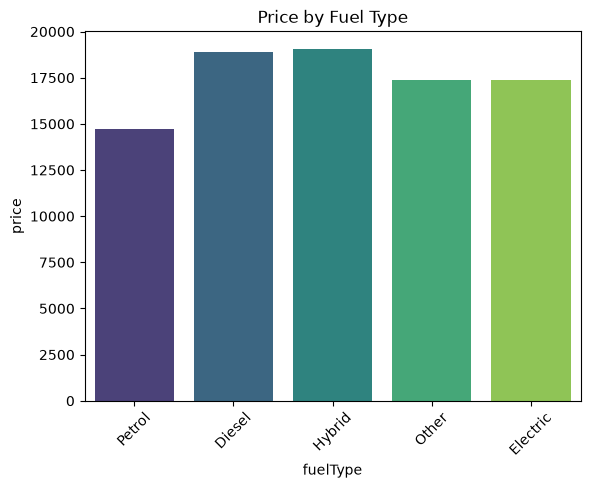

In [8]:
sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

## Conclusions on Price by Fuel Type

- Petrol-fueled cars are the cheapest category;
- Hybrid-fueled cars have the highest average prices;
- Diesel-fueled cars have average prices very close to the highest category, represented by hybrid cars, with a difference of approximately 200 GBP;
- Petrol vehicles have a considerably lower average price compared to the other main fuel categories;
- Fuel type can help the model predict the price of a car, but it should be interpreted together with the manufacturing year, engine size, make and model;
- The higher average price of hybrid vehicles may be explained by the fact that they generally use newer technology and are often newer models;

🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


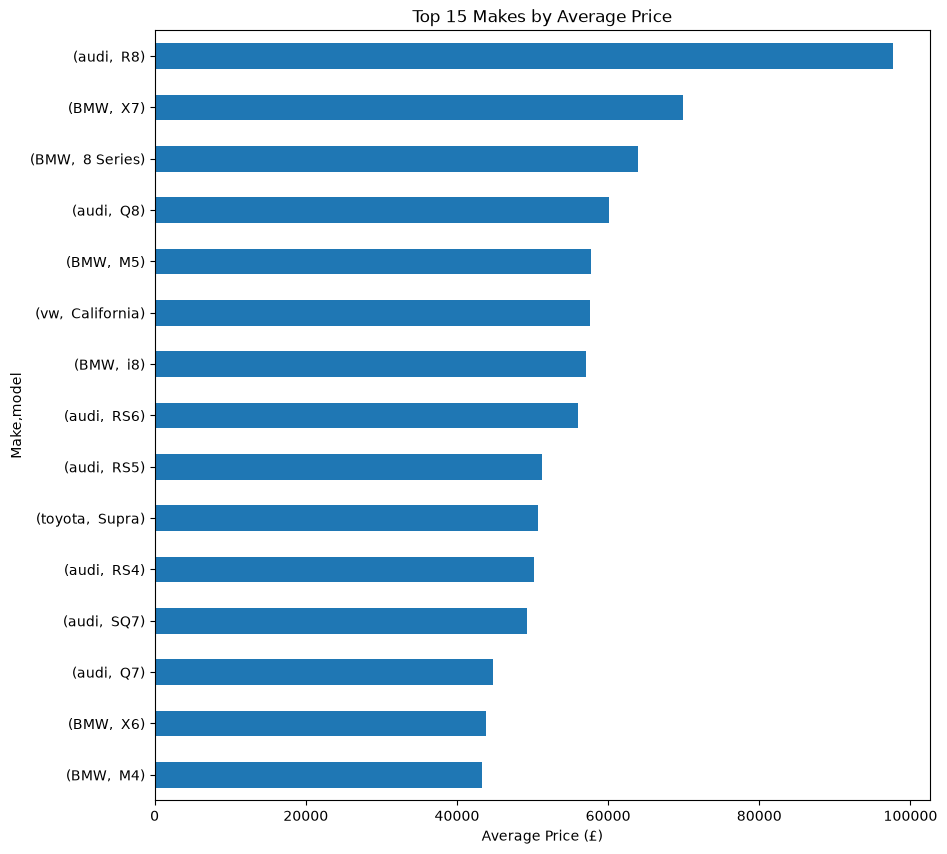

In [9]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=False).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

##  Conclusions on the Most expensive Make-Model Combination 

- Audi and BMW have the highest average prices among the car makes represented in the dataset;
- Ford has the lowest average price among the analysed makes;
- To compare car brands directly, the data should be grouped only by Make, without taking the individual model into account;
- Grouping the data by both Make and model provides a more detailed comparison, but it represents make–model combinations rather than the average price of the entire brand;
- The highest average prices are generally associated with newer models, especially vehicles manufactured during the last two years represented in the dataset;
- Overall, the results suggest that both the manufacturer and the specific model are important factors in determining the price of a car.

📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

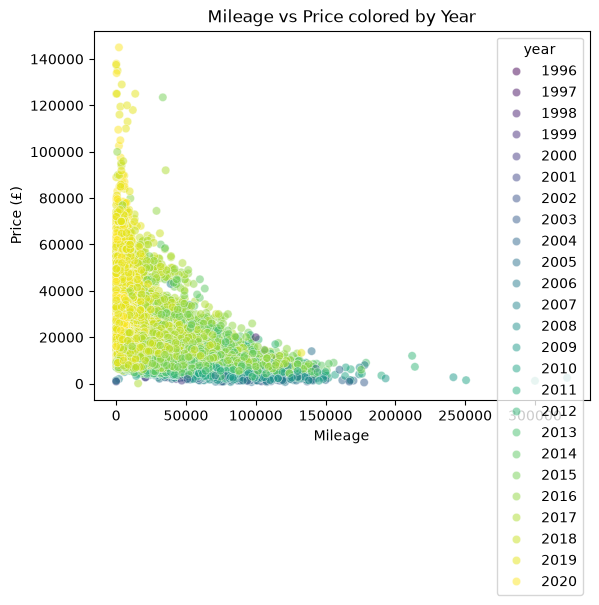

In [10]:
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, hue='year', palette='viridis', legend='full')
plt.title('Mileage vs Price colored by Year')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

##  Conclusions on Mileage vs Price

- Assigning a variable to hue map its levels to the color of the plots;
- hue = year different colors for each year;
- The newest cars, especially those manufactured between 2018 and 2020, generally have low mileage and high prices;
- As cars get older, their mileage generally increases, which contributes to their lower prices;
- There is an overall negative relationship between mileage and price: as mileage increases, the price of the car generally decreases;
- Cars with low mileage show a wider range of prices because their value also depends on the make, model, engine size and manufacturing year.

📅 6. Price vs Year
Understand how newer cars are priced.

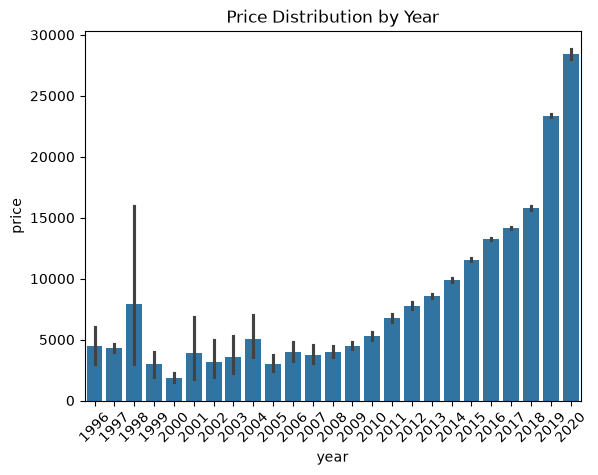

In [11]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

## Conclusions on Price distribution by year of fabrication

- We can observe that between 1996 and 2008, car prices are relatively uniform, without a clear and continuous increasing trend;
- Starting from approximately 2009, average car prices generally begin to increase from one manufacturing year to another;
- Starting from 2018, the increase in average prices becomes considerably more noticeable;
- Newer cars are generally more expensive because they use newer technology, include more modern features and have experienced less depreciation;
- Newer vehicles also tend to have lower mileage and better overall condition, which may contribute to their higher prices;
- Older vehicles generally have lower prices because their value decreases over time through depreciation;
- Some of the older manufacturing years contain very few vehicles, which means that the average prices calculated for those years may be unstable or unrepresentative;
- Overall, the graph shows a clear tendency for newer vehicles to have higher average prices, with a stronger increase during the most recent years represented in the dataset.

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

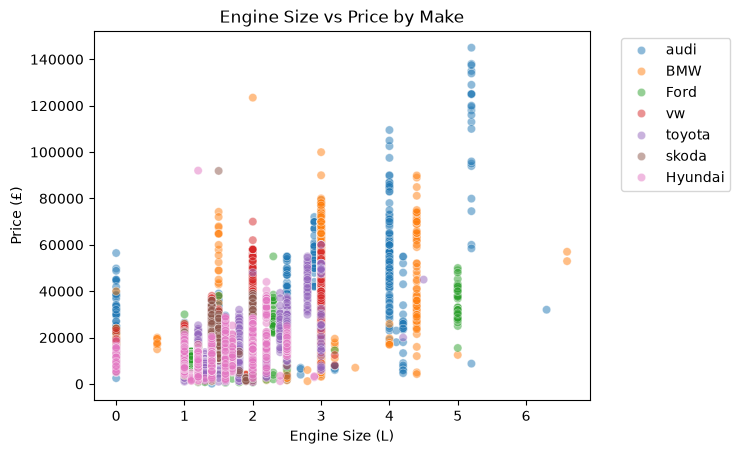

In [12]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5, hue='Make', palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

## Conclusions on Engine Size vs Price by Make

- There is a clear and strong relationship between engine size and vehicle price, meaning that engine size contains important information for estimating the final price;
- As engine size increases, the price of the vehicle generally increases as well;
- Cars with larger engines are often more expensive because they are commonly associated with premium, luxury or high-performance models;
- Most cars in the dataset have medium-sized engines, approximately between 1 and 3 L;
- Vehicles with very large engines are less common, but they are generally found in the higher price ranges;
- We can observe that some manufacturers use relatively similar and consistent engine sizes across most of their models;
- Overall, the plot indicates that larger engines are generally associated with higher vehicle prices, while differences between manufacturers and models explain much of the remaining variation.

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

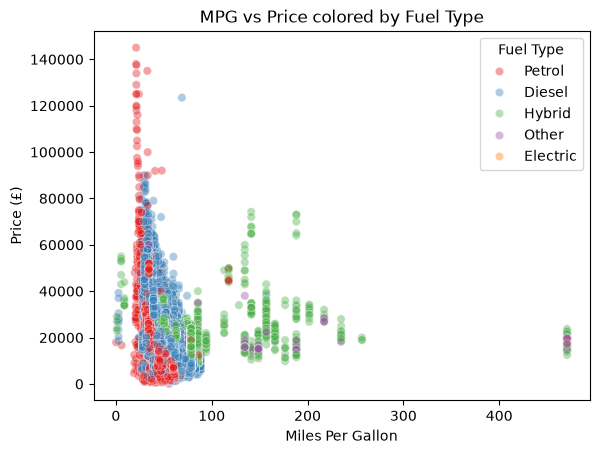

In [13]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

## Conclusions on MPG vs Price

- The relationship between MPG and price is generally negative, meaning that cars with higher MPG values tend to have lower prices;
- Fuel type create distinct clusters in the graph, showing that the relationship between MPG and price differs across fuel categories;
- Petrol vehicles appear to have more similar MPG values, but their prices vary considerably;
- Hybrid cars appear to have more consistent prices, while their MPG values vary considerably;
- Vehicles with similar MPG values can have very different prices depending on their make, model, manufacturing year, mileage and engine size;
- Overall, MPG is a useful supporting feature, but it is not one of the factors that can independently determine the final price of a car.

### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

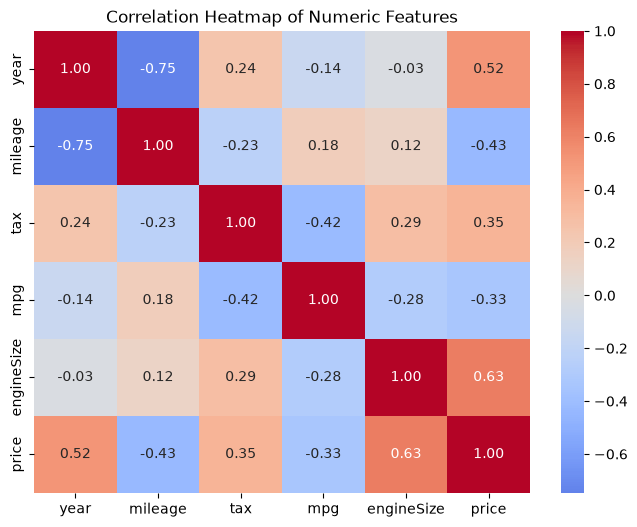

In [14]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [15]:
corr = df.corr(numeric_only=True)


C:\Users\ClimDiana-Florentina\AppData\Local\Temp\ipykernel_15708\3789713215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


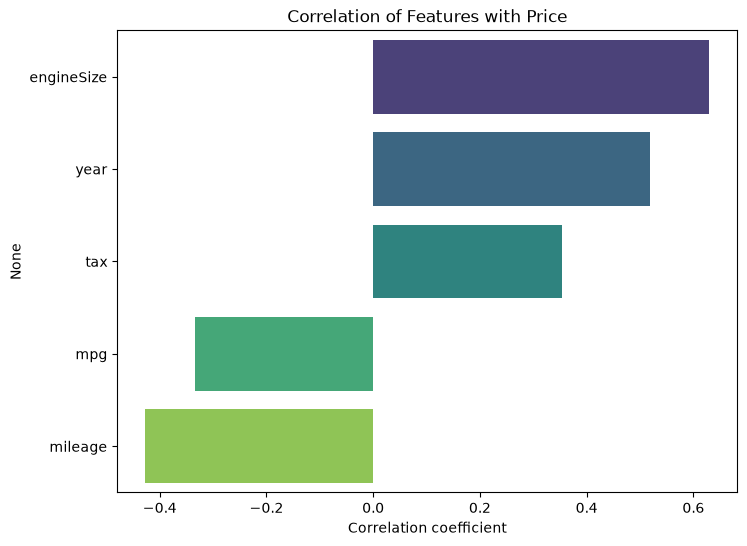

In [16]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

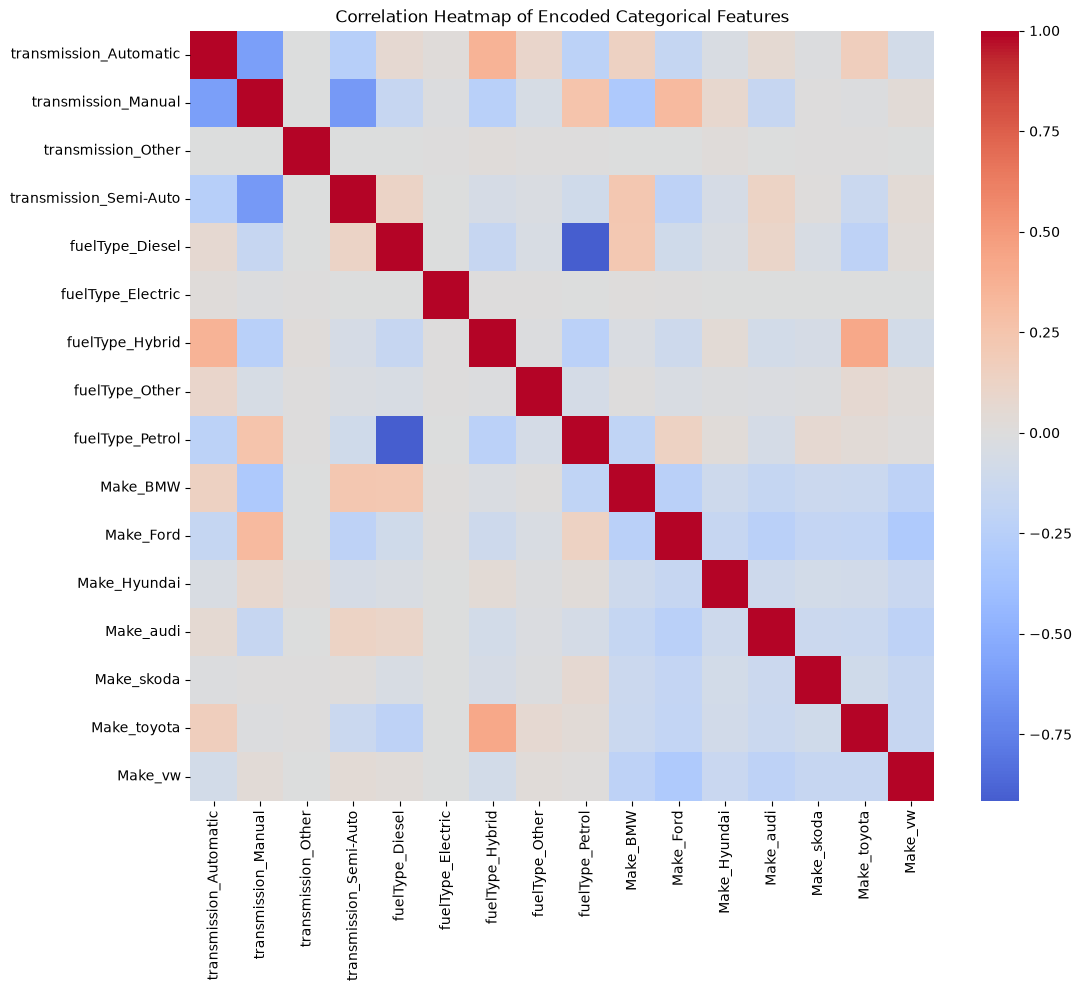

In [17]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

## Final conclusions

- Most vehicles in the dataset are concentrated in the affordable and mid-range price categories, especially between 10,000 and 20,000 GBP;
- Extremely low and extremely high prices should be inspected before training, but they should not be removed automatically because some of them may represent valid vehicles;
- Semi-automatic cars have the highest average price, while manual cars have the lowest average price among the main transmission categories;
- Hybrid and diesel vehicles have similar average prices, while petrol vehicles are generally associated with lower prices;
- Audi and BMW have some of the highest average prices in the dataset, while Ford vehicles generally belong to a lower average price category;
- The specific car model contains more detailed price information than the manufacturer alone, as large price differences can exist between models produced by the same brand;
- Engine size has a strong positive relationship with price and appears to be one of the most important numerical features for predicting vehicle prices;
- No individual feature can completely determine the price of a car. The final price results from the combination of manufacturing year, mileage, engine size, make, model, transmission and fuel type;
- Categorical features such as make, model, transmission and fuel type must be converted into numerical values before they can be used by the regression model;
- The dataset contains considerably more examples of affordable and mid-range cars than luxury vehicles, so the model may produce more accurate predictions for the most common price ranges;
- Predictions for rare, luxury and high-performance vehicles may be less accurate because the model has fewer similar examples from which to learn;
- Overall, the analysis shows that manufacturing year, mileage, engine size, make and model are among the most useful features for predicting the final price of a vehicle.

### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection: 
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

#### Let's exemplify these two new features that were engineered based on already existing columns:

In [18]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,9
1,2016,10
2,2016,10
3,2017,9
4,2019,7


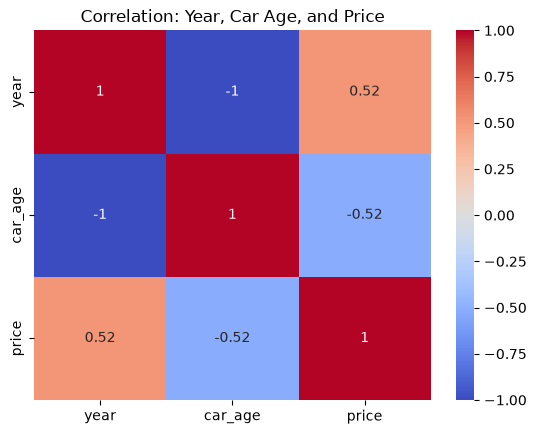

In [19]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [20]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

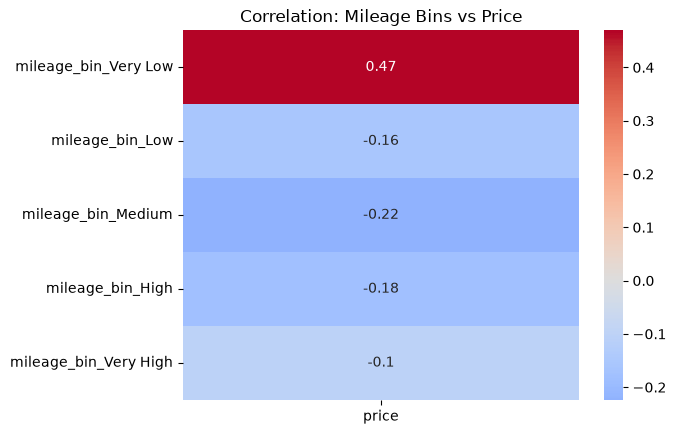

In [21]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

#### TODO: is it helpful?
-try other ones

#### Let's go back to the dataset, since we have enough information

In [22]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi,9,Low
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi,10,Medium
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi,10,Low
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi,9,Low
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi,7,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai,10,Low
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai,11,Medium
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai,9,Low
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai,8,Low


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [23]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)

# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [24]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_bin_encoded,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,1,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,10,2,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,10,1,True,False,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,9,1,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,7,0,True,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,1,True,False,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,11,2,True,False,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,9,1,True,False,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,8,1,True,False,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [25]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']  
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,True,False,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,True,False,False,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,True,False,False,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,True,False,False,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,True,False,False,False,False,False,True,False,True,False,False,False,False


In [26]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [27]:
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20,64.2,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145,67.3,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145,49.6,1.0,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,1,0,0,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30,65.7,1.7,1,0,0,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20,60.1,1.0,1,0,0,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145,44.8,1.6,1,0,0,0,0,0,1,0,1,0,0,0,0


#### TODO: Consider improvements like Standardization or Normalization:

| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.

# Random Forest Regressor

In [31]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((57948, 18), (14487, 18), (57948,), (14487,))


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

In [33]:
# Initialize and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)


### 4. Cross-validation
- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
- Tune hyperparameters via grid search or random search within CV.

### TODO: perform cross-validation and choose best model! Play with parameters

### 5. Train final model on full training data
- Once hyperparameters are set, train model on all training data.

In [34]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o


### 6. Evaluate on test data
- Predict on test set.
- Calculate key metrics like:  
  - MAE (Mean Absolute Error)  
  - RMSE (Root Mean Squared Error)  
  - R² (Coefficient of Determination)


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1322.35
RMSE: 2322.26
R²: 0.939


MAE (Mean Absolute Error) = 1321.57
On average, your model's predicted car prices are off by about $1,322 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2323.89
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,324 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.939
This means your model explains about 93.9% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.939 is excellent — your model predicts prices very well.

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

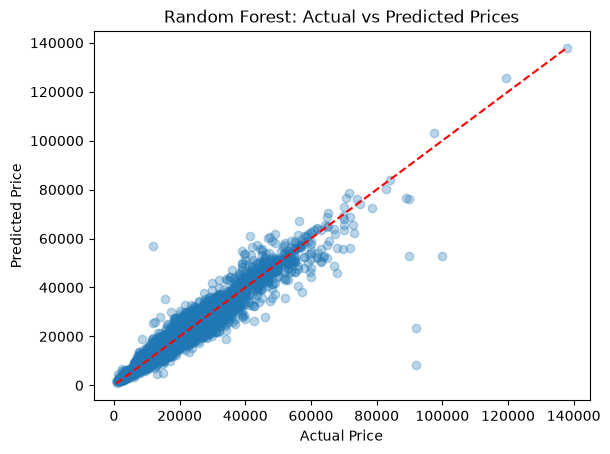

In [36]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#### TODO: How well it fit the regression line?

## Conclusions on Actual vs Predicted Prices 

- Most predicted prices are located close to the ideal regression line, indicating that the Random Forest model produces accurate predictions.
- The model performs particularly well for cars in the low and medium price ranges, where most observations are concentrated.
- The dispersion of the points increases for more expensive vehicles, meaning that the prediction errors become larger as the car price increases.
- A few significant outliers can be observed, especially among vehicles with very high actual prices.
- Some points are located above the ideal line, meaning that the model overestimated their prices, while points below the line represent underestimated prices.
- Overall, the plot confirms the strong performance indicated by the R² score of approximately 0.939.

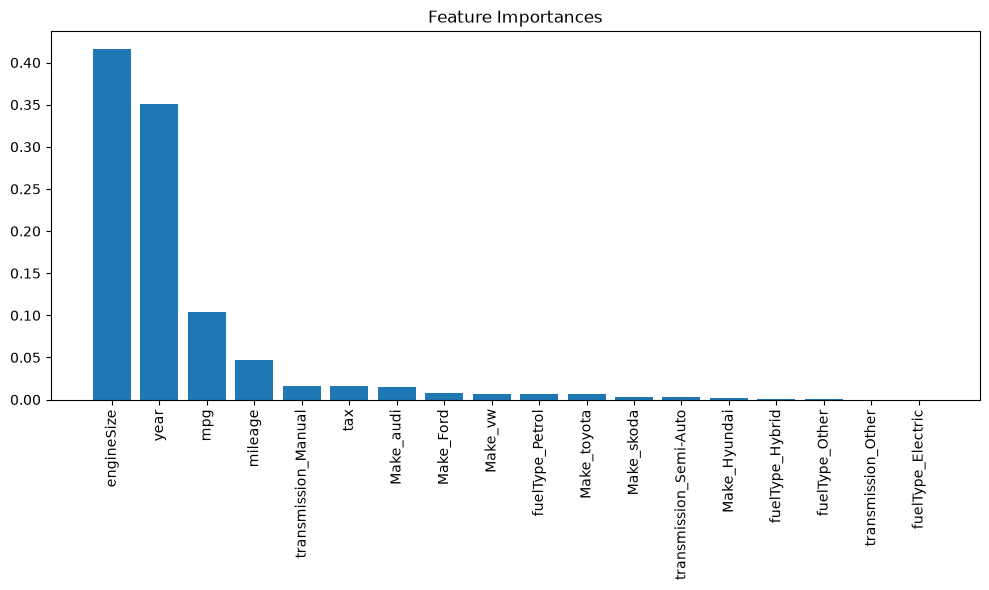

In [37]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,engineSize,0.416633
0,year,0.350467
3,mpg,0.104264
1,mileage,0.046521
5,transmission_Manual,0.016193
2,tax,0.015982
14,Make_audi,0.015007
12,Make_Ford,0.007598
17,Make_vw,0.006442
11,fuelType_Petrol,0.006276


In [39]:
feature_importance.head(10)

,Feature,Importance
4,engineSize,0.416633
0,year,0.350467
3,mpg,0.104264
1,mileage,0.046521
5,transmission_Manual,0.016193
2,tax,0.015982
14,Make_audi,0.015007
12,Make_Ford,0.007598
17,Make_vw,0.006442
11,fuelType_Petrol,0.006276


In [40]:
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
)

feature_importance.head(10)

,Feature,Importance,Importance (%)
4,engineSize,0.416633,41.663331
0,year,0.350467,35.046713
3,mpg,0.104264,10.426370
1,mileage,0.046521,4.652056
5,transmission_Manual,0.016193,1.619293
2,tax,0.015982,1.598198
14,Make_audi,0.015007,1.500707
12,Make_Ford,0.007598,0.759845
17,Make_vw,0.006442,0.644238
11,fuelType_Petrol,0.006276,0.627621


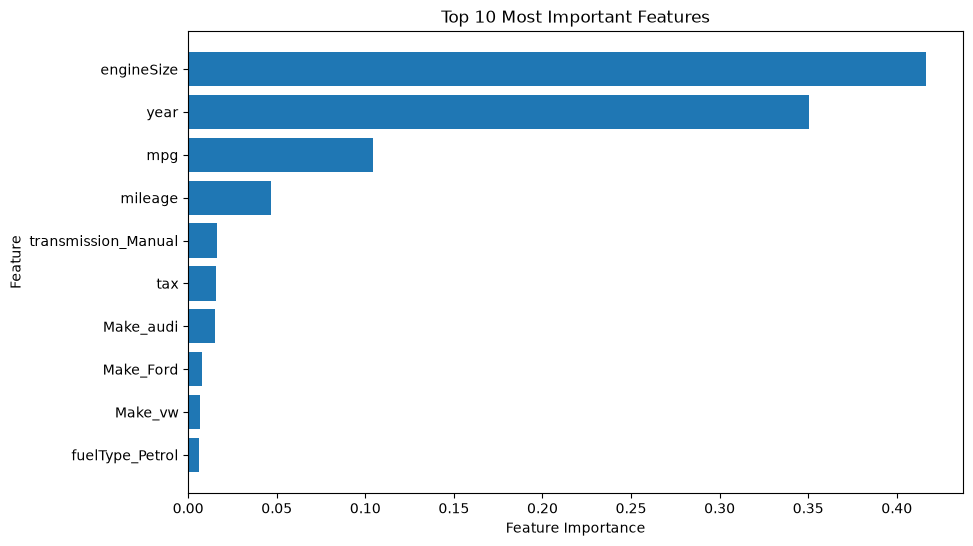

In [41]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()
plt.show()

## Conclusions on Feature Importance 

* The feature importance analysis shows which variables contributed the most to the predictions made by the Random Forest model.
* Features with higher importance values were used more frequently or produced more useful splits across the decision trees.
* The manufacturing year, mileage and engine size are expected to be among the most influential numerical features because they are strongly related to the condition, age and performance of a vehicle.
* The encoded make and transmission variables may also have an important influence because different brands and transmission types belong to different price segments.
* Features with low importance contributed less to the predictions, but they should not be removed automatically without testing the model again.
* Feature importance indicates the strength of a feature's contribution, but it does not show whether the feature increases or decreases the predicted price.











### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.

### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.


## TODO: Find the next notebook here in Regression folder, it contains a dataset about house pricings in the USA. Perform Regression and all the learned techniques on it!!! :) Have fun !

# Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 1493.91, -0.09, -1.59,...,-2384.06,-4138.29, -816.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['year','mileage','tax',...,'Make_skoda','Make_toyota','Make_vw']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.005e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [43]:
y_pred_lr = lr.predict(X_test)

In [44]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R²: {r2_lr:.3f}")

Linear Regression MAE: 2862.82
Linear Regression RMSE: 4576.58
Linear Regression R²: 0.764


In [45]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae],
    "RMSE": [rmse_lr, rmse],
    "R²": [r2_lr, r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,2862.822889,4576.582299,0.763714
1,Random Forest,1322.350424,2322.257733,0.939162


In [46]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

In [47]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [48]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [49]:
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "MAE Mean": -scores["test_MAE"].mean(),
        "MAE Std": scores["test_MAE"].std(),
        "RMSE Mean": -scores["test_RMSE"].mean(),
        "RMSE Std": scores["test_RMSE"].std(),
        "R² Mean": scores["test_R2"].mean(),
        "R² Std": scores["test_R2"].std()
    })

In [50]:
cv_comparison = pd.DataFrame(cv_results)

cv_comparison = cv_comparison.sort_values(
    by="RMSE Mean"
).reset_index(drop=True)

cv_comparison

,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R² Mean,R² Std
0,Random Forest,1323.992785,16.211645,2170.179715,70.012697,0.945114,0.003771
1,Gradient Boosting,2003.520961,12.326785,3008.960723,58.775056,0.894572,0.004442
2,Linear Regression,2860.028262,15.762909,4495.282186,54.605099,0.764812,0.003865


In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can

In [52]:
print("Best parameters:")
print(random_search.best_params_)

print(
    "Best cross-validation RMSE:",
    -random_search.best_score_
)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 20}
Best cross-validation RMSE: 2183.0097696088237


In [53]:
best_rf = random_search.best_estimator_

In [54]:
best_rf_pred = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(
    mean_squared_error(y_test, best_rf_pred)
)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print(f"Optimized Random Forest MAE: {best_rf_mae:.2f}")
print(f"Optimized Random Forest RMSE: {best_rf_rmse:.2f}")
print(f"Optimized Random Forest R²: {best_rf_r2:.3f}")

Optimized Random Forest MAE: 1289.84
Optimized Random Forest RMSE: 2266.94
Optimized Random Forest R²: 0.942


In [55]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        mae,
        best_rf_mae
    ],
    "RMSE": [
        rmse,
        best_rf_rmse
    ],
    "R²": [
        r2,
        best_rf_r2
    ]
})

tuning_comparison

,Model,MAE,RMSE,R²
0,Initial Random Forest,1322.350424,2322.257733,0.939162
1,Optimized Random Forest,1289.836874,2266.936183,0.942026


In [56]:
train_pred = best_rf.predict(X_train)
test_pred = best_rf.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Difference: {train_r2 - test_r2:.3f}")

Train R²: 0.982
Test R²: 0.942
Difference: 0.040


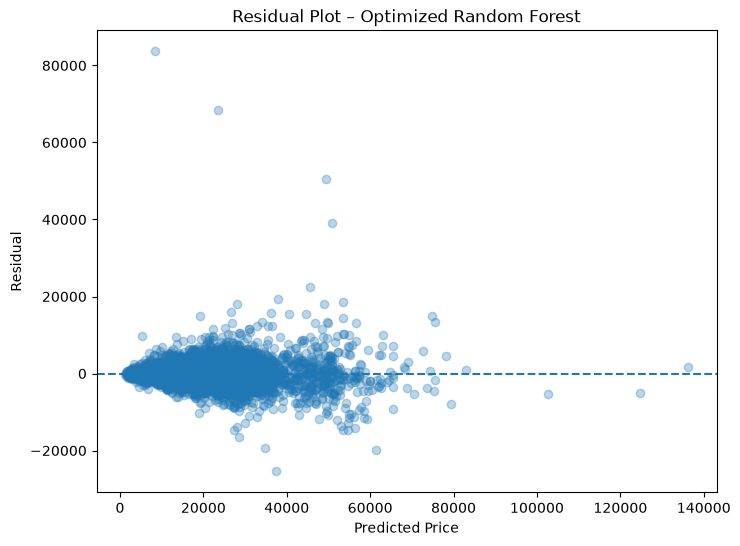

In [57]:
residuals = y_test - best_rf_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    best_rf_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot – Optimized Random Forest")

plt.show()

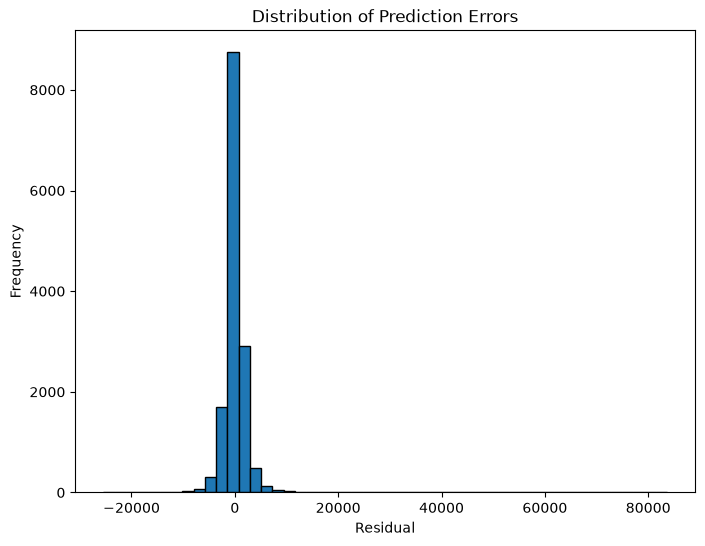

In [58]:
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=50,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

import joblib

joblib.dump(
    best_rf,
    "car_price_random_forest.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "model_features.pkl"
)

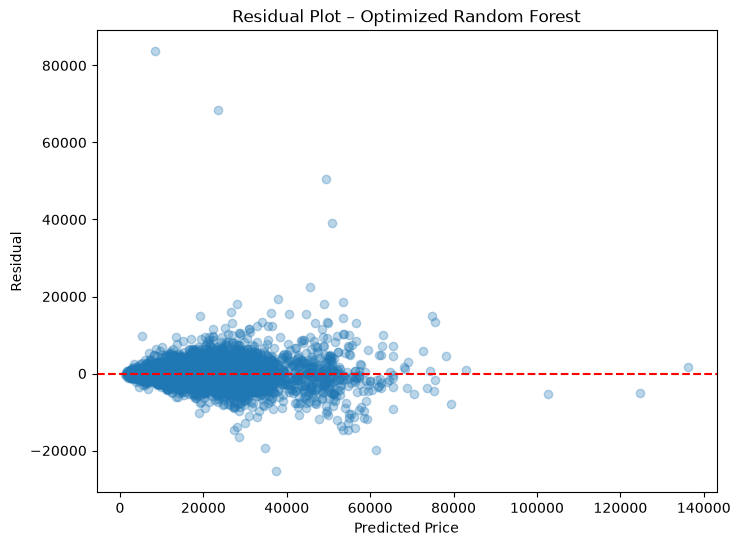

In [61]:
residuals = y_test - best_rf_pred

plt.figure(figsize=(8, 6))
plt.scatter(best_rf_pred, residuals, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot – Optimized Random Forest")

plt.show()

## Conclusions on Residual Plot 

- Most residuals are concentrated around zero, indicating that the optimized Random Forest model produces accurate predictions for most vehicles.
- The prediction errors are relatively small for cars in the low and medium price ranges.
- The spread of the residuals increases as the predicted price increases, which shows that the model is less accurate for more expensive vehicles.
- Several large positive residuals can be observed, meaning that the model significantly underestimated the prices of some unusual or expensive cars.
- Negative residuals are also present, indicating that the model sometimes overestimates vehicle prices.
- Overall, the model performs well, but its predictions are less reliable for rare and high-priced vehicles.

## Final Conclusions

- The objective of this project was to build a regression model capable of predicting car prices based on characteristics such as manufacturing year, mileage, engine size, fuel type, transmission and manufacturer.
- The categorical variables were converted into numerical features using one-hot encoding, while redundant features such as `car_age` and `mileage_bin_encoded` were removed.
- Multiple regression models were trained and compared using evaluation metrics and cross-validation.
- The optimized Random Forest Regressor obtained the best overall performance and was selected as the final model.
- The final model achieved an R² score of 0.982 on the training dataset and 0.942 on the test dataset.
- The difference of 0.040 between the training and test R² scores indicates that the model generalizes well and does not show significant overfitting.
- The Actual vs Predicted plot showed that most predictions were close to the ideal prediction line, especially for vehicles in the low and medium price ranges.
- The residual plot showed that most prediction errors were concentrated around zero, but the errors became larger for expensive and unusual vehicles.
- The model is therefore more reliable for common vehicles than for rare or high-priced cars.
- One important limitation is that the `model` feature was removed because of its high cardinality. Since different models from the same manufacturer can have significantly different prices, removing this feature may reduce prediction accuracy.
- Another limitation is that the dataset contains fewer expensive vehicles, meaning that the model has less information from which to learn their pricing patterns.
- Overall, the optimized Random Forest model provides strong predictive performance and is suitable for estimating car prices for vehicles similar to those represented in the dataset.